In [1]:
# ============================================================
# Cell 1 - Environment Setup
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib
from matplotlib import rcParams
from scipy import stats


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Matplotlib font settings
# ------------------------------------------------------------

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False


# ------------------------------------------------------------
# Global visualization settings
# ------------------------------------------------------------

rcParams.update({
    "figure.facecolor": "#1B2A4A",
    "axes.facecolor": "#243558",
    "axes.edgecolor": "#4A6080",
    "axes.labelcolor": "#FFFFFF",
    "axes.titlecolor": "#FFFFFF",
    "xtick.color": "#FFFFFF",
    "ytick.color": "#FFFFFF",
    "text.color": "#FFFFFF",
    "grid.color": "#4A6080",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor": "#4A6080",
    "legend.facecolor": "#1B2A4A",
})


# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------

BG_COLOR = "#1B2A4A"

C_GOOD = "#1D9E75"
C_BAD = "#C44E52"

In [2]:
# ============================================================
# Cell 2 - Data Loading
# ============================================================

DATA_DIR = Path("../data_collection")

raw_fin = pd.read_csv(
    DATA_DIR / "dart_earnings_financials_2019_2026.csv",
    dtype=str
)

raw_ctrl = pd.read_csv(
    DATA_DIR / "dart_financial_controls_2019_2025.csv"
)

raw_comp = pd.read_csv(
    DATA_DIR / "company_krx_fdr_controls_2019_2026.csv"
)

In [3]:
# ============================================================
# Cell 3 - Create df_hb
# ============================================================

# ------------------------------------------------------------
# Filter out non-target reports
# ------------------------------------------------------------

remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly",
    na=False,
    regex=True
)

fin = raw_fin[~remove].copy()

fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()


# ------------------------------------------------------------
# Identify consolidated financial statements
# ------------------------------------------------------------

# "연결" is retained because it is a literal string
# contained in the original Korean DART report names.
fin["is_consolidated"] = fin["report_nm"].str.contains(
    "연결",
    na=False
)

fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)

fin = fin.drop_duplicates(
    subset=["stock_code", "rcept_dt"],
    keep="first"
)


# ------------------------------------------------------------
# Classify disclosure timing
# ------------------------------------------------------------

t = fin["rcept_time"].str.split(":", expand=True)

fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")

fin["timing"] = "Intraday"

fin.loc[
    fin["_h"] < 9,
    "timing"
] = "Pre-market"

fin.loc[
    (fin["_h"] > 15)
    | ((fin["_h"] == 15) & (fin["_m"] > 30)),
    "timing"
] = "After-hours"

fin.loc[
    fin["_h"].isna(),
    "timing"
] = None

fin.drop(
    columns=["_h", "_m"],
    inplace=True
)


# ------------------------------------------------------------
# Create date and weekday variables
# ------------------------------------------------------------

fin["rcept_dt_dt"] = pd.to_datetime(
    fin["rcept_dt"],
    format="%Y%m%d"
)

fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek


# ------------------------------------------------------------
# Calculate changes in operating income
# ------------------------------------------------------------

fin["oi_won"] = pd.to_numeric(
    fin["operating_income_won"],
    errors="coerce"
)

fin = fin.sort_values(
    ["stock_code", "rcept_dt_dt"]
)

fin["prev_oi"] = (
    fin.groupby("stock_code")["oi_won"]
    .shift(1)
)

fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna()
    & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"])
    / fin["prev_oi"].abs(),
    np.nan
)


# ------------------------------------------------------------
# Classify news direction
# ------------------------------------------------------------

fin["news"] = np.select(
    [
        fin["oi_chg_pct"] > 0.10,
        fin["oi_chg_pct"] < -0.10,
        fin["oi_chg_pct"].between(
            -0.10,
            0.10,
            inclusive="both"
        )
    ],
    [
        "Good News",
        "Bad News",
        "Neutral"
    ],
    default="Missing"
)


# ------------------------------------------------------------
# Construct the analysis sample
# ------------------------------------------------------------

df = fin.copy()

df_hb = df[
    df["news"].isin(["Good News", "Bad News"])
    & df["timing"].notna()
].copy()


# ------------------------------------------------------------
# Sample summary
# ------------------------------------------------------------

print(f"Final sample: {len(df):,} observations")

print(
    f"Good News: {df['news'].eq('Good News').sum():,}  "
    f"Bad News: {df['news'].eq('Bad News').sum():,}"
)

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030


# 12. Analysis of Firms with Repeated After-Hours Disclosures

## 12.1. Objective

This section examines whether firms exhibit persistent patterns in their choice of after-hours disclosure timing.

In particular, the analysis investigates whether some firms repeatedly disclose bad news after market hours, thereby assessing whether after-hours disclosure represents a recurring firm-level pattern rather than an isolated timing choice.

To evaluate this pattern, two firm-level measures are calculated:

- **After-Hours Disclosure Ratio (After Ratio):** the proportion of a firm's total disclosures released after market hours.
- **Bad-News After-Hours Disclosure Ratio (Bad After Ratio):** the proportion of a firm's bad-news disclosures released after market hours.

These measures are used to identify whether systematic differences in disclosure-timing behavior exist across firms.

In [4]:
# ============================================================
# Cell 4 - Calculate Firm-Level After-Hours Disclosure Ratios
# ============================================================

# ------------------------------------------------------------
# Overall after-hours disclosure ratio by firm
# ------------------------------------------------------------

corp_all = (
    df_hb
    .groupby("stock_code")
    .agg(
        corp_name=("corp_name", "first"),
        total_cnt=("timing", "count"),
        after_cnt=("timing", lambda x: (x == "After-hours").sum()),
    )
    .reset_index()
)

corp_all["after_ratio"] = (
    corp_all["after_cnt"] / corp_all["total_cnt"]
)


# ------------------------------------------------------------
# Bad-news after-hours disclosure ratio by firm
# ------------------------------------------------------------

corp_bad = (
    df_hb[df_hb["news"] == "Bad News"]
    .groupby("stock_code")
    .agg(
        bad_total=("timing", "count"),
        bad_after=("timing", lambda x: (x == "After-hours").sum()),
    )
    .reset_index()
)

corp_bad["bad_after_ratio"] = (
    corp_bad["bad_after"] / corp_bad["bad_total"]
)


# ------------------------------------------------------------
# Merge firm-level measures
# ------------------------------------------------------------

corp_df = corp_all.merge(
    corp_bad,
    on="stock_code",
    how="left"
)

# Retain firms with at least four disclosures
corp_df = corp_df[
    corp_df["total_cnt"] >= 4
].copy()


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print(f"Number of firms analyzed: {len(corp_df):,}")

print("\n=== Summary Statistics for After-Hours Disclosure Ratios ===")

print(
    corp_df[
        ["after_ratio", "bad_after_ratio"]
    ]
    .describe()
    .round(3)
)

Number of firms analyzed: 530

=== Summary Statistics for After-Hours Disclosure Ratios ===
       after_ratio  bad_after_ratio
count      530.000          527.000
mean         0.418            0.463
std          0.333            0.361
min          0.000            0.000
25%          0.100            0.125
50%          0.380            0.455
75%          0.700            0.800
max          1.000            1.000


## 12.2. Descriptive Statistics

A total of **530 firms** were included in the firm-level analysis.

The distribution of firm-level after-hours disclosure ratios is summarized below.

| Statistic | Overall After-Hours Ratio | Bad-News After-Hours Ratio |
|---|---:|---:|
| Mean | 41.8% | 46.3% |
| Median | 38.0% | 45.5% |
| 25th Percentile | 10.0% | 12.5% |
| 75th Percentile | 70.0% | 80.0% |
| Maximum | 100.0% | 100.0% |

The mean overall after-hours disclosure ratio was **41.8%**, while the corresponding ratio for bad-news disclosures was higher at **46.3%**.

Similarly, the median bad-news after-hours disclosure ratio was **45.5%**, compared with **38.0%** for all disclosures.

These descriptive results indicate that, at the firm level, after-hours disclosure is more prevalent among bad-news disclosures than among disclosures overall. The pattern is consistent with firms exhibiting a greater tendency to release negative information after market hours.

---

## 12.3. Distributional Characteristics

The firm-level after-hours disclosure ratios exhibit substantial cross-sectional variation.

```text
Standard deviation of overall after-hours ratio: 0.333
Standard deviation of bad-news after-hours ratio: 0.361

In [5]:
# ============================================================
# Cell 5 - Analysis of Firms with Repeated After-Hours Bad-News Disclosures
# ============================================================

# ------------------------------------------------------------
# Identify firms with repeated after-hours bad-news disclosures
# ------------------------------------------------------------

# Firms with:
# - at least 5 bad-news disclosures
# - at least 50% of bad-news disclosures released after hours
repeat_core = (
    corp_df[
        (corp_df["bad_total"] >= 5)
        & (corp_df["bad_after_ratio"] >= 0.5)
    ]
    .copy()
    .sort_values(
        ["bad_after_ratio", "bad_total"],
        ascending=[False, False]
    )
)


# ------------------------------------------------------------
# Create percentage columns
# ------------------------------------------------------------

repeat_core["Bad-News After-Hours Ratio (%)"] = (
    repeat_core["bad_after_ratio"] * 100
).round(1)

repeat_core["Overall After-Hours Ratio (%)"] = (
    repeat_core["after_ratio"] * 100
).round(1)


# ------------------------------------------------------------
# Construct output table
# ------------------------------------------------------------

repeat_core_df = (
    repeat_core[
        [
            "corp_name",
            "stock_code",
            "bad_total",
            "bad_after",
            "Bad-News After-Hours Ratio (%)",
            "total_cnt",
            "Overall After-Hours Ratio (%)"
        ]
    ]
    .rename(columns={
        "corp_name": "Firm Name",
        "stock_code": "Stock Code",
        "bad_total": "Bad-News Disclosures",
        "bad_after": "Bad-News After-Hours Disclosures",
        "total_cnt": "Total Disclosures"
    })
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Add ranking index
# ------------------------------------------------------------

repeat_core_df.index += 1
repeat_core_df.index.name = "Rank"


# ------------------------------------------------------------
# Display Top 20 firms
# ------------------------------------------------------------

print("=== Top 20 Firms with Repeated After-Hours Bad-News Disclosures ===")

display(
    repeat_core_df.head(20)
)


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

summary_df = pd.DataFrame({
    "Category": [
        "Firms with Bad-News After-Hours Ratio > 70%",
        "Firms with Bad-News After-Hours Ratio > 50%",
        "Firms with Bad-News After-Hours Ratio = 100%"
    ],
    "Number of Firms": [
        int((corp_df["bad_after_ratio"] > 0.7).sum()),
        int((corp_df["bad_after_ratio"] > 0.5).sum()),
        int((corp_df["bad_after_ratio"] == 1.0).sum())
    ]
})

print("\n=== Summary of Firms with Repeated After-Hours Disclosures ===")

display(
    summary_df
)


# ------------------------------------------------------------
# Styled Top 20 table
# ------------------------------------------------------------

styled_repeat_core_df = (
    repeat_core_df.head(20)
    .style
    .background_gradient(
        subset=[
            "Bad-News After-Hours Ratio (%)",
            "Overall After-Hours Ratio (%)"
        ],
        cmap="Reds"
    )
    .format({
        "Bad-News After-Hours Ratio (%)": "{:.1f}%",
        "Overall After-Hours Ratio (%)": "{:.1f}%"
    })
)

styled_repeat_core_df

=== Top 20 Firms with Repeated After-Hours Bad-News Disclosures ===


,Firm Name,Stock Code,Bad-News Disclosures,Bad-News After-Hours Disclosures,Bad-News After-Hours Ratio (%),Total Disclosures,Overall After-Hours Ratio (%)
Rank,,,,,,,
1,웹젠,069080,14.0,14.0,100.0,23,100.0
2,제주은행,006220,13.0,13.0,100.0,26,100.0
3,한샘,009240,13.0,13.0,100.0,24,95.8
4,LX하우시스,108670,13.0,13.0,100.0,26,100.0
5,HS효성첨단소재,298050,13.0,13.0,100.0,22,95.5
6,한국공항,005430,11.0,11.0,100.0,21,100.0
7,호텔신라,008770,11.0,11.0,100.0,25,100.0
8,BGF,027410,11.0,11.0,100.0,24,83.3
9,하나투어,039130,11.0,11.0,100.0,21,85.7



=== Summary of Firms with Repeated After-Hours Disclosures ===


,Category,Number of Firms
0,Firms with Bad-News After-Hours Ratio > 70%,163
1,Firms with Bad-News After-Hours Ratio > 50%,225
2,Firms with Bad-News After-Hours Ratio = 100%,79


,Firm Name,Stock Code,Bad-News Disclosures,Bad-News After-Hours Disclosures,Bad-News After-Hours Ratio (%),Total Disclosures,Overall After-Hours Ratio (%)
Rank,,,,,,,
1,웹젠,069080,14.000000,14.000000,100.0%,23,100.0%
2,제주은행,006220,13.000000,13.000000,100.0%,26,100.0%
3,한샘,009240,13.000000,13.000000,100.0%,24,95.8%
4,LX하우시스,108670,13.000000,13.000000,100.0%,26,100.0%
5,HS효성첨단소재,298050,13.000000,13.000000,100.0%,22,95.5%
6,한국공항,005430,11.000000,11.000000,100.0%,21,100.0%
7,호텔신라,008770,11.000000,11.000000,100.0%,25,100.0%
8,BGF,027410,11.000000,11.000000,100.0%,24,83.3%
9,하나투어,039130,11.000000,11.000000,100.0%,21,85.7%


Number of firms with at least 5 bad-news disclosures: 388

=== Summary Statistics for the Incremental Gap ===
count    388.000
mean       0.040
std        0.107
min       -0.417
25%       -0.004
50%        0.015
75%        0.093
max        0.467
Name: incremental_gap, dtype: float64

=== Top 20 Firms by Positive Incremental Gap ===


,Firm Name,Stock Code,Overall After-Hours Ratio,Bad-News After-Hours Ratio,Incremental Gap (Bad News - Overall),Total Disclosures,Bad-News Disclosures
Rank,,,,,,,
1,가온그룹,078890,33.3%,80.0%,+46.7%,12,5.000000
2,에이치시티,072990,38.5%,83.3%,+44.9%,13,6.000000
3,키다리스튜디오,020120,61.5%,100.0%,+38.5%,13,5.000000
4,한미반도체,042700,30.0%,66.7%,+36.7%,20,9.000000
5,종근당,185750,35.3%,71.4%,+36.1%,17,7.000000
6,아바코,083930,48.0%,83.3%,+35.3%,25,12.000000
7,코스맥스비티아이,044820,66.7%,100.0%,+33.3%,12,5.000000
8,코스맥스,192820,50.0%,83.3%,+33.3%,14,6.000000
9,원익QnC,074600,53.3%,85.7%,+32.4%,15,7.000000



=== Number of Firms by Incremental-Gap Threshold ===


,Category,Number of Firms
0,Gap > 0,204
1,Gap > 10 percentage points,86
2,Gap > 20 percentage points,28
3,Gap > 30 percentage points,11
4,Gap > 50 percentage points,0
5,Gap = 0,86
6,Gap < 0,98


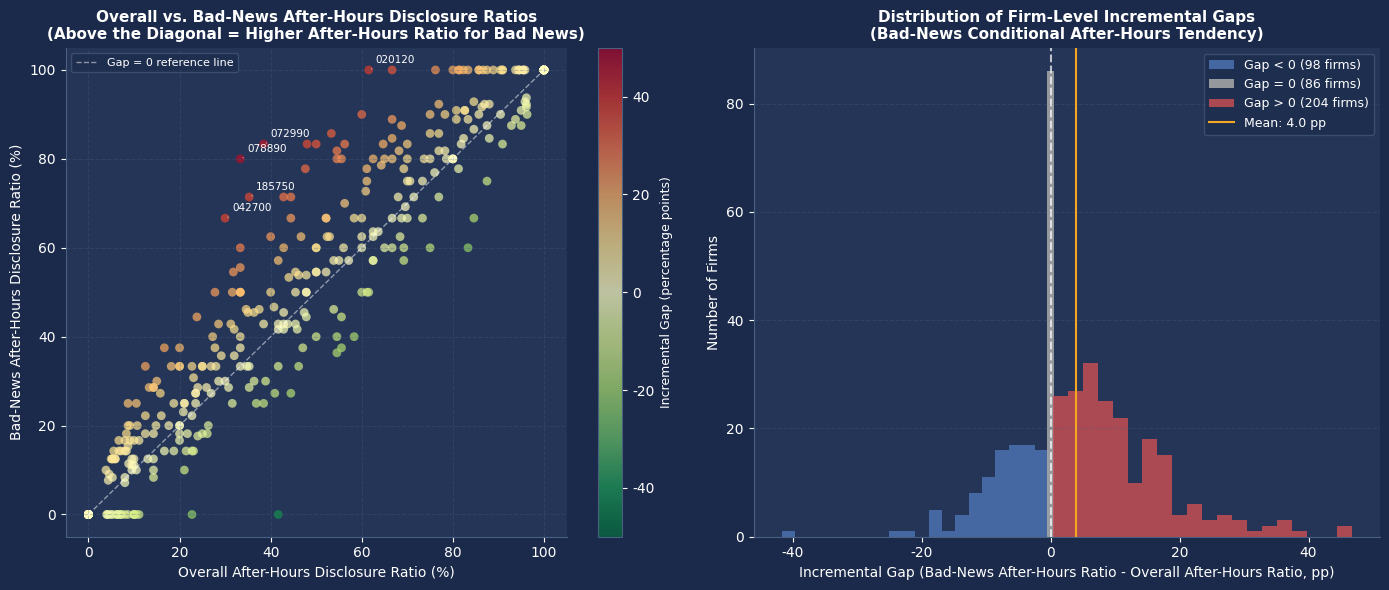


=== Summary ===
Total firms analyzed: 388
Gap > 0 (higher after-hours ratio for bad news): 204 firms (52.6%)
Gap = 0 (no difference): 86 firms (22.2%)
Gap < 0 (lower after-hours ratio for bad news): 98 firms (25.3%)
Mean incremental gap: 3.98 pp
Median incremental gap: 1.49 pp


In [7]:
# ============================================================
# Cell X - Conditional After-Hours Disclosure Tendency for Bad News
# (Based on bad_after_ratio - after_ratio)
# ============================================================


# ------------------------------------------------------------
# 1. Calculate the incremental gap
# ------------------------------------------------------------

# Retain firms for which both bad_after_ratio
# and after_ratio are available
corp_gap = corp_df.dropna(
    subset=["bad_after_ratio"]
).copy()

corp_gap["incremental_gap"] = (
    corp_gap["bad_after_ratio"]
    - corp_gap["after_ratio"]
)


# ------------------------------------------------------------
# 2. Define the analysis sample
# ------------------------------------------------------------

# Retain firms with at least 5 bad-news disclosures
# to reduce instability from very small firm-level samples
corp_gap_filtered = corp_gap[
    corp_gap["bad_total"] >= 5
].copy()

print(
    f"Number of firms with at least 5 bad-news disclosures: "
    f"{len(corp_gap_filtered):,}"
)

print("\n=== Summary Statistics for the Incremental Gap ===")

print(
    corp_gap_filtered["incremental_gap"]
    .describe()
    .round(3)
)


# ------------------------------------------------------------
# 3. Firms with the largest positive incremental gaps
# ------------------------------------------------------------

# A larger positive incremental gap indicates that a firm's
# after-hours disclosure ratio is higher for bad news
# than for its disclosures overall
top_gap = (
    corp_gap_filtered[
        corp_gap_filtered["incremental_gap"] > 0
    ]
    .sort_values(
        "incremental_gap",
        ascending=False
    )
    .head(20)
    .copy()
)


# ------------------------------------------------------------
# Construct display table
# ------------------------------------------------------------

top_gap_display = top_gap[
    [
        "corp_name",
        "stock_code",
        "after_ratio",
        "bad_after_ratio",
        "incremental_gap",
        "total_cnt",
        "bad_total"
    ]
].copy()

top_gap_display.index = range(
    1,
    len(top_gap_display) + 1
)

top_gap_display.index.name = "Rank"

top_gap_display.columns = [
    "Firm Name",
    "Stock Code",
    "Overall After-Hours Ratio",
    "Bad-News After-Hours Ratio",
    "Incremental Gap (Bad News - Overall)",
    "Total Disclosures",
    "Bad-News Disclosures"
]

print(
    "\n=== Top 20 Firms by Positive Incremental Gap ==="
)

display(
    top_gap_display.style
    .format({
        "Overall After-Hours Ratio": "{:.1%}",
        "Bad-News After-Hours Ratio": "{:.1%}",
        "Incremental Gap (Bad News - Overall)": "{:+.1%}",
    })
    .background_gradient(
        subset=[
            "Incremental Gap (Bad News - Overall)"
        ],
        cmap="Reds"
    )
    .background_gradient(
        subset=[
            "Overall After-Hours Ratio"
        ],
        cmap="Blues"
    )
)


# ------------------------------------------------------------
# 4. Number of firms by incremental-gap threshold
# ------------------------------------------------------------

gap_summary = pd.DataFrame({
    "Category": [
        "Gap > 0",
        "Gap > 10 percentage points",
        "Gap > 20 percentage points",
        "Gap > 30 percentage points",
        "Gap > 50 percentage points",
        "Gap = 0",
        "Gap < 0",
    ],
    "Number of Firms": [
        int(
            (
                corp_gap_filtered["incremental_gap"] > 0
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] > 0.10
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] > 0.20
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] > 0.30
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] > 0.50
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] == 0
            ).sum()
        ),
        int(
            (
                corp_gap_filtered["incremental_gap"] < 0
            ).sum()
        ),
    ]
})

print(
    "\n=== Number of Firms by Incremental-Gap Threshold ==="
)

display(gap_summary)


# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

fig.patch.set_facecolor(BG_COLOR)


# ============================================================
# 5-1. Scatter Plot:
# Overall vs. Bad-News After-Hours Disclosure Ratios
# ============================================================

ax = axes[0]

ax.set_facecolor("#243558")

sc = ax.scatter(
    corp_gap_filtered["after_ratio"] * 100,
    corp_gap_filtered["bad_after_ratio"] * 100,
    c=corp_gap_filtered["incremental_gap"] * 100,
    cmap="RdYlGn_r",
    alpha=0.7,
    s=40,
    edgecolors="none",
    vmin=-50,
    vmax=50,
)


# Gap = 0 reference line
ax.plot(
    [0, 100],
    [0, 100],
    color="white",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Gap = 0 reference line"
)


# ------------------------------------------------------------
# Label the five firms with the largest positive gaps
# using stock codes instead of Korean firm names
# ------------------------------------------------------------

for _, row in top_gap.head(5).iterrows():

    stock_label = str(row["stock_code"]).zfill(6)

    ax.annotate(
        stock_label,
        xy=(
            row["after_ratio"] * 100,
            row["bad_after_ratio"] * 100
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7.5,
        color="white",
        arrowprops=dict(
            arrowstyle="-",
            color="white",
            lw=0.5
        )
    )


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------

cbar = fig.colorbar(
    sc,
    ax=ax
)

cbar.set_label(
    "Incremental Gap (percentage points)",
    color="white",
    fontsize=9
)

cbar.ax.yaxis.set_tick_params(
    color="white"
)

plt.setp(
    cbar.ax.yaxis.get_ticklabels(),
    color="white"
)


# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax.set_xlabel(
    "Overall After-Hours Disclosure Ratio (%)",
    fontsize=10
)

ax.set_ylabel(
    "Bad-News After-Hours Disclosure Ratio (%)",
    fontsize=10
)

ax.set_title(
    "Overall vs. Bad-News After-Hours Disclosure Ratios\n"
    "(Above the Diagonal = Higher After-Hours Ratio for Bad News)",
    fontsize=11,
    fontweight="bold"
)

ax.legend(
    fontsize=8
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax.grid(
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


# ============================================================
# 5-2. Histogram:
# Distribution of Incremental Gaps
# ============================================================

ax2 = axes[1]

ax2.set_facecolor("#243558")

gap_vals = (
    corp_gap_filtered["incremental_gap"] * 100
)

n_pos = int(
    (gap_vals > 0).sum()
)

n_zero = int(
    (gap_vals == 0).sum()
)

n_neg = int(
    (gap_vals < 0).sum()
)


# ------------------------------------------------------------
# Negative incremental gaps
# ------------------------------------------------------------

ax2.hist(
    gap_vals[gap_vals < 0],
    bins=20,
    color="#4C72B0",
    alpha=0.85,
    label=f"Gap < 0 ({n_neg} firms)",
    edgecolor="none"
)


# ------------------------------------------------------------
# Zero incremental gaps
# ------------------------------------------------------------

ax2.hist(
    gap_vals[gap_vals == 0],
    bins=1,
    color="#AAAAAA",
    alpha=0.85,
    label=f"Gap = 0 ({n_zero} firms)",
    edgecolor="none"
)


# ------------------------------------------------------------
# Positive incremental gaps
# ------------------------------------------------------------

ax2.hist(
    gap_vals[gap_vals > 0],
    bins=20,
    color="#C44E52",
    alpha=0.85,
    label=f"Gap > 0 ({n_pos} firms)",
    edgecolor="none"
)


# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax2.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

ax2.axvline(
    gap_vals.mean(),
    color="#F5A623",
    linestyle="-",
    linewidth=1.5,
    label=f"Mean: {gap_vals.mean():.1f} pp"
)


# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax2.set_xlabel(
    "Incremental Gap "
    "(Bad-News After-Hours Ratio - Overall After-Hours Ratio, pp)",
    fontsize=10
)

ax2.set_ylabel(
    "Number of Firms",
    fontsize=10
)

ax2.set_title(
    "Distribution of Firm-Level Incremental Gaps\n"
    "(Bad-News Conditional After-Hours Tendency)",
    fontsize=11,
    fontweight="bold"
)

ax2.legend(
    fontsize=9
)

ax2.spines[
    ["top", "right"]
].set_visible(False)

ax2.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax2.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_X_incremental_gap_analysis.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

n_firms = len(corp_gap_filtered)

print("\n=== Summary ===")

print(
    f"Total firms analyzed: {n_firms:,}"
)

print(
    f"Gap > 0 "
    f"(higher after-hours ratio for bad news): "
    f"{n_pos:,} firms "
    f"({n_pos / n_firms * 100:.1f}%)"
)

print(
    f"Gap = 0 "
    f"(no difference): "
    f"{n_zero:,} firms "
    f"({n_zero / n_firms * 100:.1f}%)"
)

print(
    f"Gap < 0 "
    f"(lower after-hours ratio for bad news): "
    f"{n_neg:,} firms "
    f"({n_neg / n_firms * 100:.1f}%)"
)

print(
    f"Mean incremental gap: "
    f"{gap_vals.mean():.2f} pp"
)

print(
    f"Median incremental gap: "
    f"{gap_vals.median():.2f} pp"
)

### Analysis of Bad-News Conditional After-Hours Disclosure Tendency

The difference between each firm's overall after-hours disclosure ratio and its bad-news after-hours disclosure ratio reveals that some firms exhibit a stronger tendency to disclose after market hours specifically when releasing bad news.

To quantify this pattern, a firm-level **incremental gap** was calculated as follows:

$$
\text{Incremental Gap}
=
\text{Bad-News After-Hours Ratio}
-
\text{Overall After-Hours Ratio}
$$

A positive incremental gap indicates that a firm's after-hours disclosure ratio is higher for bad-news disclosures than for its disclosures overall.

Among the **388 firms** with at least five bad-news disclosures, the mean incremental gap was **4.0 percentage points**, while the median was **1.5 percentage points**.

This suggests that, on average, firms in the sample exhibited a modestly higher propensity to release disclosures after market hours when the information was negative.

The distribution of incremental gaps was as follows:

| Category | Number of Firms |
|---|---:|
| Gap > 0 | 204 |
| Gap = 0 | 86 |
| Gap < 0 | 98 |

Accordingly, **52.6%** of firms had a higher after-hours disclosure ratio for bad news, **22.2%** showed no difference, and **25.3%** had a lower after-hours disclosure ratio for bad news.

These results indicate substantial cross-firm heterogeneity. The bad-news conditional after-hours pattern is therefore not uniform across firms, but appears to be more pronounced among a subset of firms.

Several firms exhibited particularly large positive incremental gaps. Examples include:

- **Gaon Group:** +46.7 percentage points
- **HCT:** +44.9 percentage points
- **KidariStudio:** +38.5 percentage points
- **Hanmi Semiconductor:** +36.7 percentage points
- **Chong Kun Dang:** +36.1 percentage points

For example, Gaon Group's overall after-hours disclosure ratio was **33.3%**, whereas its bad-news after-hours disclosure ratio increased to **80.0%**.

Similarly, Hanmi Semiconductor had an overall after-hours disclosure ratio of approximately **30.0%**, compared with **66.7%** for bad-news disclosures.

These cases are consistent with the possibility that some firms do not simply exhibit a generally high preference for after-hours disclosure, but instead show a relatively stronger after-hours tendency specifically when disclosing negative information.

The threshold analysis provides further evidence of heterogeneity:

- **86 firms** had an incremental gap greater than **10 percentage points**
- **28 firms** exceeded **20 percentage points**
- **11 firms** exceeded **30 percentage points**

At the same time, a substantial number of firms exhibited either zero or negative incremental gaps. This indicates that some firms maintained broadly similar disclosure-timing patterns regardless of news direction, while others had a lower after-hours disclosure ratio for bad news.

Taken together, the results suggest that bad-news after-hours disclosure is not a uniform market-wide behavior. Instead, the pattern appears to be concentrated more strongly among certain firms.

This finding is also consistent with the earlier logistic regression results, in which bad-news status and bad-news severity were significantly associated with a higher probability of after-hours disclosure. The incremental-gap analysis therefore provides complementary firm-level evidence that a bad-news conditional after-hours disclosure tendency may exist for a subset of firms.

## 12.5. Analysis of Firms with Repeated After-Hours Disclosures

The firm-level analysis reveals that some firms exhibit particularly strong patterns of repeated after-hours bad-news disclosure.

Several firms recorded:

```text
Bad-News After-Hours Ratio = 100%
```

indicating that all of their bad-news disclosures observed during the analysis period were released after market hours.

Examples include:

- Webzen
- Jeju Bank
- Hanssem
- LX Hausys
- Hotel Shilla
- HL Mando
- Hyosung TNC

These firms each had approximately **9–14 bad-news disclosures**, all of which were released after market hours. Given the number of observations involved, these cases represent notable firm-level patterns of repeated after-hours disclosure rather than isolated individual events.

Some firms also exhibited extremely high after-hours disclosure ratios across their disclosures overall.

| Firm | Overall After-Hours Ratio |
|---|---:|
| Webzen | 100.0% |
| Jeju Bank | 100.0% |
| Hotel Shilla | 100.0% |
| HL Mando | 100.0% |
| Korea Petrochemical Ind. | 100.0% |

These cases suggest that some firms may have persistent firm-level tendencies toward releasing disclosures after market hours regardless of news direction.

Other firms, however, recorded a 100% bad-news after-hours ratio despite having a comparatively lower overall after-hours disclosure ratio.

| Firm | Overall After-Hours Ratio | Bad-News After-Hours Ratio |
|---|---:|---:|
| Lotte Hi-Mart | 81.5% | 100.0% |
| HanaTour | 85.7% | 100.0% |
| BGF | 83.3% | 100.0% |

For these firms, the concentration of bad-news disclosures after market hours is greater than their general tendency to disclose after hours.

This distinction is important because a high bad-news after-hours ratio may reflect either a firm's general preference for after-hours disclosure or an additional tendency associated specifically with negative information. The incremental-gap analysis presented above helps distinguish between these two patterns.

---

## 12.6. Summary of Repeated After-Hours Disclosure Patterns

The firm-level analysis indicates that a substantial number of firms released a high proportion of their bad-news disclosures after market hours.

| Category | Number of Firms |
|---|---:|
| Bad-News After-Hours Ratio > 50% | 225 |
| Bad-News After-Hours Ratio > 70% | 163 |
| Bad-News After-Hours Ratio = 100% | 79 |

Among the **530 firms** included in the overall firm-level analysis, **225 firms (approximately 42%)** released more than half of their bad-news disclosures after market hours.

Furthermore, **163 firms** released more than 70% of their bad-news disclosures after hours, while **79 firms** recorded a bad-news after-hours ratio of 100% during the analysis period.

These descriptive findings indicate that repeated after-hours bad-news disclosure is not confined to only a small number of firms. Instead, high after-hours ratios are observed across a substantial subset of the sample.

The presence of firms with consistently high after-hours disclosure ratios also points to substantial persistence in firm-level disclosure-timing behavior. However, a 100% bad-news after-hours ratio alone does not establish that disclosure timing reflects a deliberate strategic policy, as such ratios may also be influenced by firm-specific reporting practices, disclosure schedules, or other unobserved factors.

This result is consistent with the earlier logistic regression analysis, in which:

```text
past_after_ratio
```

was a significant predictor of after-hours disclosure.

Taken together, the findings suggest that firms exhibit persistence in their disclosure-timing patterns and that, for some firms, this persistence is particularly pronounced for bad-news disclosures. Combined with the incremental-gap analysis, the results provide evidence of substantial firm-level heterogeneity: some firms exhibit a generally high tendency toward after-hours disclosure, while others show a comparatively stronger after-hours tendency specifically when releasing negative information.

In [8]:
# ============================================================
# Cell 6 - Year-to-Year Persistence Analysis
# ============================================================


# ------------------------------------------------------------
# 1. Create year variable
# ------------------------------------------------------------

df_hb["year"] = df_hb["rcept_dt_dt"].dt.year


# ------------------------------------------------------------
# 2. Calculate annual bad-news after-hours ratio by firm
# ------------------------------------------------------------

corp_year = (
    df_hb[
        df_hb["news"] == "Bad News"
    ]
    .groupby(
        ["stock_code", "corp_name", "year"]
    )
    .agg(
        bad_total=(
            "timing",
            "count"
        ),
        bad_after=(
            "timing",
            lambda x: (x == "After-hours").sum()
        ),
    )
    .reset_index()
)

corp_year["bad_after_ratio"] = (
    corp_year["bad_after"]
    / corp_year["bad_total"]
)

# Retain firm-year observations with at least one bad-news disclosure
corp_year = corp_year[
    corp_year["bad_total"] >= 1
].copy()


# ------------------------------------------------------------
# 3. Annual average bad-news after-hours disclosure ratio
# ------------------------------------------------------------

year_avg = (
    corp_year
    .groupby("year")["bad_after_ratio"]
    .agg([
        "mean",
        "median",
        "count"
    ])
    .reset_index()
)

year_avg.columns = [
    "year",
    "mean_ratio",
    "median_ratio",
    "n_firms"
]


print(
    "=== Annual Bad-News After-Hours Disclosure Ratios ==="
)

print(
    year_avg
    .round(3)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. Persistence of high after-hours disclosure ratios
# ------------------------------------------------------------

# Count the number of years in which each firm had
# a bad-news after-hours disclosure ratio above 50%
persistent = (
    corp_year[
        corp_year["bad_after_ratio"] > 0.5
    ]
    .groupby("stock_code")["year"]
    .count()
    .reset_index()
)

persistent.columns = [
    "stock_code",
    "years_above_50pct"
]


# ------------------------------------------------------------
# 5. Add firm names
# ------------------------------------------------------------

persistent = persistent.merge(
    corp_df[
        ["stock_code", "corp_name"]
    ],
    on="stock_code",
    how="left"
)

persistent = persistent.sort_values(
    "years_above_50pct",
    ascending=False
)


# ------------------------------------------------------------
# 6. Display firms with the most persistent patterns
# ------------------------------------------------------------

print(
    "\n=== Firms with the Most Years of "
    "Bad-News After-Hours Ratio > 50% ==="
)

print(
    persistent
    .head(15)
    .to_string(index=False)
)

=== Annual Bad-News After-Hours Disclosure Ratios ===
 year  mean_ratio  median_ratio  n_firms
 2019       0.492         0.500      267
 2020       0.442         0.222      342
 2021       0.442         0.333      349
 2022       0.457         0.500      388
 2023       0.467         0.500      416
 2024       0.488         0.500      405
 2025       0.478         0.500      415

=== Firms with the Most Years of Bad-News After-Hours Ratio > 50% ===
stock_code  years_above_50pct corp_name
    298000                  7      효성화학
    005430                  7      한국공항
    009240                  7        한샘
    204320                  7      HL만도
    214320                  7       이노션
    145720                  7       덴티움
    008770                  7      호텔신라
    108670                  7    LX하우시스
    006220                  7      제주은행
    071840                  7    롯데하이마트
    027410                  7       BGF
    067830                  7   세이브존I&C
    069080                 

## 12.7. Year-to-Year Persistence of After-Hours Bad-News Disclosures

The annual analysis indicates that the average firm-level after-hours disclosure ratio for bad news remained relatively stable throughout the sample period.

### Annual Bad-News After-Hours Disclosure Ratios

| Year | Mean Ratio | Median Ratio | Number of Firms |
|---|---:|---:|---:|
| 2019 | 49.2% | 50.0% | 267 |
| 2020 | 44.2% | 22.2% | 342 |
| 2021 | 44.2% | 33.3% | 349 |
| 2022 | 45.7% | 50.0% | 388 |
| 2023 | 46.7% | 50.0% | 416 |
| 2024 | 48.8% | 50.0% | 405 |
| 2025 | 47.8% | 50.0% | 415 |

Across the sample period, the mean firm-level bad-news after-hours disclosure ratio remained within a relatively narrow range of approximately:

```text
44%–49%
```

From 2022 onward, the median ratio remained at:

```text
50%
```

This indicates that the typical firm in these annual samples released approximately half of its bad-news disclosures after market hours.

Despite changes in the number of firms represented each year, the mean ratio did not exhibit a substantial or sustained decline. The descriptive evidence therefore suggests that the prevalence of after-hours bad-news disclosure was relatively persistent over time rather than being concentrated in a single year or short period.

---

The persistence analysis at the firm level further shows that some firms maintained:

```text
Bad-News After-Hours Ratio > 50%
```

in all seven years of the analysis period.

### Firms with Bad-News After-Hours Ratios Above 50% in All Seven Years

| Firm | Number of Years |
|---|---:|
| Hyosung Chemical | 7 |
| Korea Airport Service | 7 |
| Hanssem | 7 |
| HL Mando | 7 |
| Innocean | 7 |
| Dentium | 7 |
| Hotel Shilla | 7 |
| LX Hausys | 7 |
| Jeju Bank | 7 |
| Lotte Hi-Mart | 7 |
| BGF | 7 |
| Savezone I&C | 7 |
| Webzen | 7 |
| Cafe24 | 7 |
| HanaTour | 7 |

These firms exhibited a bad-news after-hours disclosure ratio above 50% in every year in which they were included in the annual analysis across the seven-year sample period.

The consistency of this pattern suggests that disclosure timing may exhibit substantial persistence at the firm level. For some firms, a high tendency to release bad news after market hours appears repeatedly across multiple years rather than being confined to isolated disclosure events.

However, the annual firm-level ratios should be interpreted with caution because the calculation includes firm-year observations with at least one bad-news disclosure. A firm with only a small number of bad-news disclosures in a given year can therefore exhibit an extreme annual ratio, such as 0% or 100%, based on very few observations. Accordingly, the results provide descriptive evidence of persistence but do not by themselves establish a stable or deliberate disclosure-timing strategy.

The findings are also consistent with the earlier repeated-disclosure analysis and the logistic regression results. In particular:

```text
past_after_ratio
```

was a significant predictor of after-hours disclosure.

Taken together, these results suggest that firms exhibit persistence in their disclosure-timing behavior over time. For a subset of firms, high after-hours disclosure ratios for bad news recur across multiple years, providing additional firm-level evidence that historical disclosure-timing patterns are associated with subsequent timing choices.

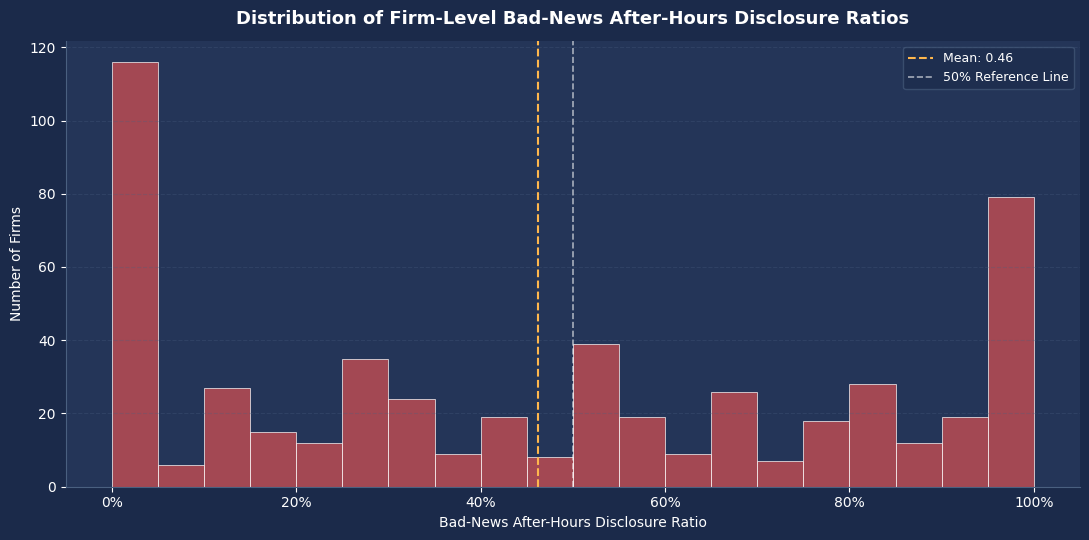

In [9]:
# ============================================================
# Cell 7 - Visualization 1:
# Distribution of Bad-News After-Hours Disclosure Ratios
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.5))

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")


# ------------------------------------------------------------
# Prepare plot data
# ------------------------------------------------------------

plot_data = corp_df["bad_after_ratio"].dropna()


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

ax.hist(
    plot_data,
    bins=20,
    color="#C44E52",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6
)


# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax.axvline(
    plot_data.mean(),
    color="#FFB74D",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {plot_data.mean():.2f}"
)

ax.axvline(
    0.5,
    color="white",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    label="50% Reference Line"
)


# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax.set_xlabel(
    "Bad-News After-Hours Disclosure Ratio",
    fontsize=10
)

ax.set_ylabel(
    "Number of Firms",
    fontsize=10
)

ax.set_title(
    "Distribution of Firm-Level Bad-News After-Hours Disclosure Ratios",
    fontsize=13,
    fontweight="bold",
    pad=12
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)

ax.legend(
    fontsize=9
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_1_bad_after_ratio_dist.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

## 12.8. Distribution of Firm-Level Bad-News After-Hours Disclosure Ratios

The distribution of firm-level bad-news after-hours disclosure ratios exhibits substantial dispersion, with relatively large concentrations of firms near both **0% and 100%**.

This pattern indicates considerable heterogeneity in disclosure-timing behavior across firms. While some firms released relatively few of their bad-news disclosures after market hours, others released most or all of their bad-news disclosures after hours.

The mean firm-level bad-news after-hours disclosure ratio was:

```text
46.3%
```

while the median was approximately:

```text
45%–50%
```

These statistics indicate that after-hours disclosures account for a substantial proportion of bad-news disclosures for the typical firm in the sample.

However, the distribution is widely dispersed rather than tightly concentrated around its mean. In particular, the relatively high frequencies near the boundaries of **0% and 100%** indicate that firm-level disclosure-timing patterns differ substantially across the sample.

This dispersion is also consistent with the standard deviations reported in the preceding descriptive analysis:

```text
Standard deviation of overall after-hours ratio: 0.333
Standard deviation of bad-news after-hours ratio: 0.361
```

The larger dispersion of the bad-news after-hours ratio provides further descriptive evidence of substantial cross-firm heterogeneity in disclosure timing.

The concentration of observations near 100% is also consistent with the preceding analysis identifying firms that repeatedly released bad-news disclosures after market hours. However, these extreme ratios should be interpreted cautiously because firm-level ratios can be affected by the number of bad-news disclosures observed for each firm. A 100% ratio alone therefore does not establish a deliberate or persistent disclosure strategy.

Taken together with the repeated-disclosure and year-to-year persistence analyses, the distribution suggests that after-hours disclosure behavior varies substantially across firms. Some firms exhibit consistently high after-hours disclosure ratios, whereas others rarely use after-hours disclosure.

This pattern is also consistent with the earlier logistic regression results, in which:

```text
past_after_ratio
```

was a significant predictor of after-hours disclosure.

Overall, the results suggest that historical firm-level disclosure-timing patterns are associated with subsequent timing choices. The distributional evidence therefore complements the regression and persistence analyses by demonstrating substantial heterogeneity in firms' use of after-hours disclosure, particularly for bad-news announcements.

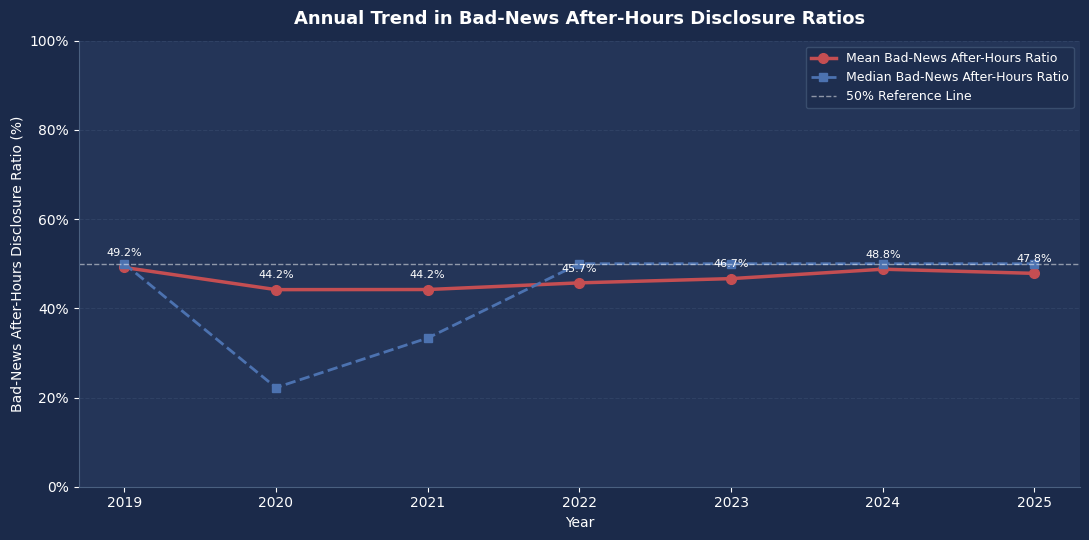

In [10]:
# ============================================================
# Cell 8 - Visualization 2:
# Annual Trend in Bad-News After-Hours Disclosure Ratios
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.5))

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")


# ------------------------------------------------------------
# Plot annual mean and median ratios
# ------------------------------------------------------------

ax.plot(
    year_avg["year"],
    year_avg["mean_ratio"] * 100,
    color="#C44E52",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Mean Bad-News After-Hours Ratio"
)

ax.plot(
    year_avg["year"],
    year_avg["median_ratio"] * 100,
    color="#4C72B0",
    linewidth=2,
    marker="s",
    markersize=6,
    linestyle="--",
    label="Median Bad-News After-Hours Ratio"
)


# ------------------------------------------------------------
# 50% reference line
# ------------------------------------------------------------

ax.axhline(
    50,
    color="white",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="50% Reference Line"
)


# ------------------------------------------------------------
# Add mean-value labels
# ------------------------------------------------------------

for _, row in year_avg.iterrows():

    ax.text(
        row["year"],
        row["mean_ratio"] * 100 + 2.5,
        f"{row['mean_ratio'] * 100:.1f}%",
        ha="center",
        fontsize=8,
        color="white"
    )


# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax.set_xlabel(
    "Year",
    fontsize=10
)

ax.set_ylabel(
    "Bad-News After-Hours Disclosure Ratio (%)",
    fontsize=10
)

ax.set_title(
    "Annual Trend in Bad-News After-Hours Disclosure Ratios",
    fontsize=13,
    fontweight="bold",
    pad=12
)


# ------------------------------------------------------------
# Fix the y-axis at 0-100% to avoid visually exaggerating
# relatively small year-to-year differences
# ------------------------------------------------------------

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100)
)

ax.set_xticks(
    year_avg["year"]
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)

ax.legend(
    fontsize=9
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_2_bad_after_ratio_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

## 12.9. Annual Trend in Bad-News After-Hours Disclosure Ratios

The annual analysis shows that the mean firm-level after-hours disclosure ratio for bad news remained relatively stable throughout the sample period.

### Annual Bad-News After-Hours Disclosure Ratios

| Year | Mean Bad-News After-Hours Ratio | Median Bad-News After-Hours Ratio |
|---|---:|---:|
| 2019 | 49.2% | 50.0% |
| 2020 | 44.2% | 22.2% |
| 2021 | 44.2% | 33.3% |
| 2022 | 45.7% | 50.0% |
| 2023 | 46.7% | 50.0% |
| 2024 | 48.8% | 50.0% |
| 2025 | 47.8% | 50.0% |

Across the sample period, the mean bad-news after-hours disclosure ratio remained within a relatively narrow range of approximately:

```text
44%–49%
```

This indicates that after-hours disclosures consistently accounted for a substantial proportion of firms' bad-news disclosures throughout the analysis period.

From 2022 onward, the median firm-level ratio remained at:

```text
50%
```

indicating that the median firm-year observation had half of its bad-news disclosures released after market hours.

---

The median ratio was notably lower in **2020 (22.2%)** and **2021 (33.3%)**, while the corresponding mean remained approximately **44%**.

The divergence between the mean and median indicates an asymmetric cross-sectional distribution of firm-level ratios during these years. It is consistent with the presence of firms with relatively high after-hours ratios raising the mean above the median. However, the descriptive statistics alone do not establish which firms or how many firms were responsible for this difference.

---

The annual mean also shows no clear sustained upward or downward trend over the sample period. For example:

- **2019:** 49.2%
- **2024:** 48.8%
- **2025:** 47.8%

Thus, although year-to-year fluctuations are present, the magnitude of the variation is relatively modest, with the annual mean remaining between approximately 44% and 49%.

The visualization uses a **0%–100% y-axis** so that these year-to-year differences are shown in proportion to the full range of the disclosure ratio rather than visually magnified by a truncated axis.

The persistence of similar annual averages provides descriptive evidence that after-hours bad-news disclosure was not concentrated in only one particular year or short subperiod. However, the annual pattern alone cannot establish that the behavior reflects a structural or deliberate disclosure strategy, since changes in firm composition, disclosure frequency, and other time-varying factors may also affect the annual ratios.

---

Taken together, the annual results indicate that the prevalence of after-hours bad-news disclosure remained relatively stable over the 2019–2025 period.

This finding is consistent with the preceding firm-level persistence analysis and the earlier logistic regression results, in which:

```text
past_after_ratio
```

was a significant predictor of after-hours disclosure.

Overall, the evidence suggests persistence in firms' disclosure-timing behavior over time. Combined with the firm-level analyses, the annual results provide complementary evidence that historical disclosure-timing patterns are associated with subsequent timing choices, while substantial heterogeneity remains across individual firms.

## 12.10. Overall Interpretation

Taken together, the firm-level analyses reveal substantial heterogeneity in after-hours disclosure behavior across firms.

A considerable number of firms repeatedly released bad-news disclosures after market hours, while some firms exhibited particularly high bad-news after-hours disclosure ratios throughout the analysis period. The year-to-year analysis further indicates that high after-hours disclosure tendencies persisted across multiple years for a subset of firms rather than appearing only in isolated periods.

These findings suggest that disclosure timing is associated with persistent firm-level practices rather than being determined solely by isolated disclosure events or short-term circumstances. However, the descriptive evidence alone cannot establish whether these persistent patterns reflect deliberate strategic behavior, firm-specific reporting routines, or other unobserved factors.

The analysis also provides evidence that persistence is not explained solely by firms' general tendency to disclose after hours. In the incremental-gap analysis, more than half of the firms with at least five bad-news disclosures exhibited a higher after-hours disclosure ratio for bad news than for their disclosures overall.

For some firms, the difference was particularly pronounced, with bad-news after-hours disclosure ratios exceeding their overall after-hours ratios by approximately **30–45 percentage points**.

This pattern suggests that, for a subset of firms, the concentration of bad-news disclosures after market hours cannot be attributed entirely to a generally high propensity for after-hours disclosure. Instead, these firms exhibit an additional after-hours tendency specifically associated with negative information.

Combined with the earlier logistic regression results, particularly the significant association of `past_after_ratio`, bad-news status, and bad-news severity with after-hours disclosure, the firm-level evidence points to two related patterns:

1. **Persistent firm-level disclosure-timing behavior:** some firms consistently exhibit relatively high after-hours disclosure tendencies over time.
2. **Bad-news conditional after-hours tendency:** for a subset of firms, the after-hours disclosure ratio is higher for bad news than for their disclosures overall.

Overall, the results provide complementary evidence that after-hours disclosure behavior is heterogeneous and persistent at the firm level, while also suggesting that negative information is associated with an additional tendency toward after-hours disclosure for some firms. These findings are consistent with the possibility of strategic timing behavior, but they should not be interpreted as establishing deliberate strategic intent without additional causal evidence.